In [23]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "requests", "beautifulsoup4", "lxml"])

0

In [24]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

In [25]:
url = "https://www.transfermarkt.com/tschechien/startseite/verein/3445"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers)
print("Status code:", response.status_code)

Status code: 200


In [26]:
def scrape_squad(url, eur_to_mxn=23.5):
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.content, "lxml")
    table = soup.find("table", {"class": "items"})
    
    df = pd.read_html(StringIO(str(table)))[0]
    df = df.dropna(subset=[df.columns[0]])
    df = df.reset_index(drop=True)

    # Split Player + Position
    positions = [
        "Goalkeeper",
        "Centre-Back", "Left-Back", "Right-Back", "Defender",
        "Defensive Midfield", "Central Midfield", "Attacking Midfield",
        "Left Midfield", "Right Midfield", "Midfielder",
        "Left Winger", "Right Winger",
        "Centre-Forward", "Second Striker", "Forward"
    ]
    pattern = "|".join(positions)
    df["Position"] = df["Player"].str.extract(f"({pattern})")
    df["Player"] = df["Player"].str.replace(f"({pattern})", "", regex=True).str.strip()

    # Age
    if "Date of birth/Age" in df.columns:
        df["Age"] = df["Date of birth/Age"].str.extract(r"\((\d+)\)").astype(int)
        df = df.drop(columns=["Date of birth/Age"])

    # Market Value
    df["Market value"] = df["Market value"].apply(parse_market_value)
    df["Market Value MXN"] = df["Market value"] * eur_to_mxn

    return df


In [27]:
def parse_market_value(val):
    if pd.isna(val):
        return None
    val = str(val).replace("€", "").strip()
    if "m" in val:
        return float(val.replace("m", "")) * 1_000_000
    elif "k" in val:
        return float(val.replace("k", "")) * 1_000
    return float(val)


In [28]:
import plotly.graph_objects as go

def plot_squad_values(df_values, title="Valor en mercado del equipo (MXN)", colors=["steelblue", "tomato", "gold", "mediumseagreen"]):
    df_sorted = df_values.sort_values("Market Value MXN", ascending=True)
    colors = colors

    fig = go.Figure()

    fig.add_trace(go.Bar(
        x=df_sorted["Market Value MXN"],
        y=df_sorted["Team"],
        orientation="h",
        marker=dict(color=colors, line=dict(width=0)),
        text=df_sorted["Market Value MXN"].apply(lambda x: f"${x:,.0f}"),
        textposition="inside"
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Valor en el mercado (MXN)",
        yaxis_title="Equipo",
        template="plotly_dark",
        showlegend=False
    )

    fig.show()





###  Grupo A

In [29]:
group_a = {"Mexico":"https://www.transfermarkt.com/mexiko/startseite/verein/6303",
           "Sudafrica":"https://www.transfermarkt.com/sudafrika/startseite/verein/3806",
           "Sur Corea":"https://www.transfermarkt.com/sudkorea/startseite/verein/3589",
           "Czechia":"https://www.transfermarkt.com/tschechien/startseite/verein/3445"}

group_a_dfs = {}
for team, url in group_a.items():
    print(f"Scraping {team}...")
    group_a_dfs[team] = scrape_squad(url)
    
print("Done!")

df_group_a = pd.DataFrame([
    {
        "Team": name,
        "Market value": df["Market value"].sum(),
        "Market Value MXN": df["Market Value MXN"].sum()
    }
    for name, df in group_a_dfs.items()
])

Scraping Mexico...
Scraping Sudafrica...
Scraping Sur Corea...
Scraping Czechia...
Done!


In [30]:
plot_squad_values(df_group_a, title="Grupo A - Valor en mercado del equipo (MXN)", colors=[ "green", "white", "navy","darkgreen"])

In [31]:
group_b = {"Canada":"https://www.transfermarkt.com/kanada/startseite/verein/3510",
           "Bosnia":"https://www.transfermarkt.com/bosnien-herzegowina/startseite/verein/3446",
           "Qatar":"https://www.transfermarkt.com/katar/startseite/verein/14162",
           "Suiza":"https://www.transfermarkt.com/schweiz/startseite/verein/3384"
}

In [32]:
group_b_dfs = {}
for team, url in group_b.items():
    print(f"Scraping {team}...")
    group_b_dfs[team] = scrape_squad(url)
    
print("Done!")

Scraping Canada...
Scraping Bosnia...
Scraping Qatar...
Scraping Suiza...
Done!


In [33]:
df_group_b = pd.DataFrame([
    {
        "Team": name,
        "Market value": df["Market value"].sum(),
        "Market Value MXN": df["Market Value MXN"].sum()
    }
    for name, df in group_b_dfs.items()
])

In [34]:
plot_squad_values(df_group_b, title="Grupo B - Valor en mercado del equipo (MXN)", colors=["sienna", "gold", "crimson","red"])

### Grupo C

In [35]:
group_c = {"Brazil":"https://www.transfermarkt.com/brasilien/startseite/verein/3439",
           "Marruecos":"https://www.transfermarkt.com/marokko/startseite/verein/3575", 
           "Haiti":"https://www.transfermarkt.com/haiti/startseite/verein/14161",
           "Escocia":"https://www.transfermarkt.com/schottland/startseite/verein/3380"}

group_c_dfs = {}
for team, url in group_c.items():
    print(f"Scraping {team}...")
    group_c_dfs[team] = scrape_squad(url)
    
print("Done!")

df_group_c = pd.DataFrame([
    {
        "Team": name,
        "Market value": df["Market value"].sum(),
        "Market Value MXN": df["Market Value MXN"].sum()
    }
    for name, df in group_c_dfs.items()
])



Scraping Brazil...
Scraping Marruecos...
Scraping Haiti...
Scraping Escocia...
Done!


In [36]:
plot_squad_values(df_group_c, title="Grupo C - Valor en mercado del equipo (MXN)", colors=["mediumblue", "royalblue", "firebrick","yellow"])

### Grupo D

In [37]:
group_d = {"EEUU":"https://www.transfermarkt.com/vereinigte-staaten/startseite/verein/3505",
           "Paraguay":"https://www.transfermarkt.com/paraguay/startseite/verein/3581",
           "Australia":"https://www.transfermarkt.com/australien/startseite/verein/3433",
           "Turquia":"https://www.transfermarkt.com/turkei/startseite/verein/3381"}

group_d_dfs = {}
for team, url in group_d.items():
    print(f"Scraping {team}...")
    group_d_dfs[team] = scrape_squad(url)
    
print("Done!")

df_group_d = pd.DataFrame([
    {
        "Team": name,
        "Market value": df["Market value"].sum(),
        "Market Value MXN": df["Market Value MXN"].sum()
    }
    for name, df in group_d_dfs.items()
])

Scraping EEUU...
Scraping Paraguay...
Scraping Australia...
Scraping Turquia...
Done!


In [38]:
plot_squad_values(df_group_d, title="Grupo D - Valor en mercado del equipo (MXN)", colors=["navy", "crimson", "mediumblue","red"])

### Grupo E

In [39]:
group_e = {"Alemania":"https://www.transfermarkt.com/deutschland/startseite/verein/3262",
           "Curazao":"https://www.transfermarkt.com/curacao/startseite/verein/32364",
           "Costa de Marfil":"https://www.transfermarkt.com/elfenbeinkuste/startseite/verein/3591",
           "Ecuador":"https://www.transfermarkt.com/ecuador/startseite/verein/5750"}

group_e_dfs = {}
for team, url in group_e.items():
    print(f"Scraping {team}...")
    group_e_dfs[team] = scrape_squad(url)
    
print("Done!")

df_group_e = pd.DataFrame([
    {
        "Team": name,
        "Market value": df["Market value"].sum(),
        "Market Value MXN": df["Market Value MXN"].sum()
    }
    for name, df in group_e_dfs.items()
])

Scraping Alemania...
Scraping Curazao...
Scraping Costa de Marfil...
Scraping Ecuador...
Done!


In [40]:
plot_squad_values(df_group_e, title="Grupo E - Valor en mercado del equipo (MXN)", colors=["navy", "yellow", "orange","white"])

### Grupo F

In [41]:
group_f = {"Paises Bajos":"https://www.transfermarkt.com/niederlande/startseite/verein/3379",
           "Japon":"https://www.transfermarkt.com/japan/startseite/verein/3435",
           "Suecia":"https://www.transfermarkt.com/schweden/startseite/verein/3557",
           "Tunez":"https://www.transfermarkt.com/tunesien/startseite/verein/3670"}

group_f_dfs = {}
for team, url in group_f.items():
    print(f"Scraping {team}...")
    group_f_dfs[team] = scrape_squad(url)
    
print("Done!")

df_group_f = pd.DataFrame([
    {
        "Team": name,
        "Market value": df["Market value"].sum(),
        "Market Value MXN": df["Market Value MXN"].sum()
    }
    for name, df in group_f_dfs.items()
])

Scraping Paises Bajos...
Scraping Japon...
Scraping Suecia...
Scraping Tunez...
Done!


In [42]:
plot_squad_values(df_group_f, title="Grupo F - Valor en mercado del equipo (MXN)", colors=[ "red", "white", "navy","orange"])

### Grupo G

In [43]:
group_g = {"Belgica":"https://www.transfermarkt.com/belgien/startseite/verein/3382",
           "Egipto":"https://www.transfermarkt.com/agypten/startseite/verein/3672",
           "Iran":"https://www.transfermarkt.com/iran/startseite/verein/3582",
           "Nueva Zelanda":"https://www.transfermarkt.com/neuseeland/startseite/verein/9171"}

group_g_dfs = {}
for team, url in group_g.items():
    print(f"Scraping {team}...")
    group_g_dfs[team] = scrape_squad(url)
    
print("Done!")

df_group_g = pd.DataFrame([
    {
        "Team": name,
        "Market value": df["Market value"].sum(),
        "Market Value MXN": df["Market Value MXN"].sum()
    }
    for name, df in group_g_dfs.items()
])

Scraping Belgica...
Scraping Egipto...
Scraping Iran...
Scraping Nueva Zelanda...
Done!


In [44]:
plot_squad_values(df_group_g, title="Grupo G - Valor en mercado del equipo (MXN)", colors=[ "white", "navy", "crimson","red"])

### Group H

In [45]:
group_h = {"España":"https://www.transfermarkt.com/spanien/startseite/verein/3375",
           "Cabo Verde":"https://www.transfermarkt.com/kap-verde/startseite/verein/4311",
           "Arabia Saudita":"https://www.transfermarkt.com/saudi-arabien/startseite/verein/3807",
           "Uruguay":"https://www.transfermarkt.com/uruguay/startseite/verein/3449"}

group_h_dfs = {}
for team, url in group_h.items():
    print(f"Scraping {team}...")
    group_h_dfs[team] = scrape_squad(url)
    
print("Done!")

df_group_h = pd.DataFrame([
    {
        "Team": name,
        "Market value": df["Market value"].sum(),
        "Market Value MXN": df["Market Value MXN"].sum()
    }
    for name, df in group_h_dfs.items()
])

Scraping España...
Scraping Cabo Verde...
Scraping Arabia Saudita...
Scraping Uruguay...
Done!


In [46]:
plot_squad_values(df_group_h, title="Grupo H - Valor en mercado del equipo (MXN)", colors=[ "forestgreen", "navy", "deepskyblue","red"])

### Grupo I

In [47]:
group_i = {"Francia":"https://www.transfermarkt.com/frankreich/startseite/verein/3377",
           "Senegal":"https://www.transfermarkt.com/senegal/startseite/verein/3499",
           "Iraq":"https://www.transfermarkt.com/irak/startseite/verein/3560",
           "Noruega":"https://www.transfermarkt.com/norwegen/startseite/verein/3440"}

group_i_dfs = {}
for team, url in group_i.items():
    print(f"Scraping {team}...")
    group_i_dfs[team] = scrape_squad(url)
    
print("Done!")

df_group_i = pd.DataFrame([
    {
        "Team": name,
        "Market value": df["Market value"].sum(),
        "Market Value MXN": df["Market Value MXN"].sum()
    }
    for name, df in group_i_dfs.items()
])

Scraping Francia...
Scraping Senegal...
Scraping Iraq...
Scraping Noruega...
Done!


In [48]:
plot_squad_values(df_group_i, title="Grupo I - Valor en mercado del equipo (MXN)", colors=[ "darkgreen", "forestgreen", "red","navy"])

### Grupo J

In [49]:
group_j = {"Argentina":"https://www.transfermarkt.com/argentinien/startseite/verein/3437",
           "Algeria":"https://www.transfermarkt.com/algerien/startseite/verein/3614",
           "Austria":"https://www.transfermarkt.com/osterreich/startseite/verein/3383",
           "Jordania":"https://www.transfermarkt.com/jordanien/startseite/verein/15737"}

group_j_dfs = {}
for team, url in group_j.items():
    print(f"Scraping {team}...")
    group_j_dfs[team] = scrape_squad(url)
    
print("Done!")

df_group_j = pd.DataFrame([
    {
        "Team": name,
        "Market value": df["Market value"].sum(),
        "Market Value MXN": df["Market Value MXN"].sum()
    }
    for name, df in group_j_dfs.items()
])

Scraping Argentina...
Scraping Algeria...
Scraping Austria...
Scraping Jordania...
Done!


In [50]:
plot_squad_values(df_group_j, title="Grupo J - Valor en mercado del equipo (MXN)", colors=[ "red", "crimson", "darkgreen","deepskyblue"])

### Grupo K

In [51]:
group_k = {"Portugal":"https://www.transfermarkt.com/portugal/startseite/verein/3300",
           "Congo":"https://www.transfermarkt.com/demokratische-republik-kongo/startseite/verein/3854",
           "Uzbekistan":"https://www.transfermarkt.com/usbekistan/startseite/verein/3563",
           "Colombia":"https://www.transfermarkt.com/kolumbien/startseite/verein/3816"}

group_k_dfs = {}
for team, url in group_k.items():
    print(f"Scraping {team}...")
    group_k_dfs[team] = scrape_squad(url)
    
print("Done!")

df_group_k = pd.DataFrame([
    {
        "Team": name,
        "Market value": df["Market value"].sum(),
        "Market Value MXN": df["Market Value MXN"].sum()
    }
    for name, df in group_k_dfs.items()
])

Scraping Portugal...
Scraping Congo...
Scraping Uzbekistan...
Scraping Colombia...
Done!


In [52]:
plot_squad_values(df_group_k, title="Grupo K - Valor en mercado del equipo (MXN)", colors=[ "navy", "cornflowerblue", "gold","firebrick"])

### Grupo L

In [53]:
group_l = {"Inglaterra":"https://www.transfermarkt.com/england/startseite/verein/3299",
           "Croacia":"https://www.transfermarkt.com/kroatien/startseite/verein/3556",
           "Ghana":"https://www.transfermarkt.com/ghana/startseite/verein/3441",
           "Panama":"https://www.transfermarkt.com/panama/startseite/verein/3577"}

group_l_dfs = {}
for team, url in group_l.items():
    print(f"Scraping {team}...")
    group_l_dfs[team] = scrape_squad(url)
    
print("Done!")

df_group_l = pd.DataFrame([
    {
        "Team": name,
        "Market value": df["Market value"].sum(),
        "Market Value MXN": df["Market Value MXN"].sum()
    }
    for name, df in group_l_dfs.items()
])

Scraping Inglaterra...
Scraping Croacia...
Scraping Ghana...
Scraping Panama...
Done!


In [54]:
plot_squad_values(df_group_l, title="Grupo L - Valor en mercado del equipo (MXN)", colors=[ "red", "gold", "navy","white"])

### Save data frames

In [89]:
import os

output_dir = r"E:\VS projects\Scraper_transfermarket\data"
os.makedirs(output_dir, exist_ok=True)

all_groups = {
    "group_a": group_a_dfs,
    "group_b": group_b_dfs,
    "group_c": group_c_dfs,
    "group_d": group_d_dfs,
    "group_e": group_e_dfs,
    "group_f": group_f_dfs,
    "group_g": group_g_dfs,
    "group_h": group_h_dfs,
    "group_i": group_i_dfs,
    "group_j": group_j_dfs,
    "group_k": group_k_dfs,
    "group_l": group_l_dfs,
}

for group_name, group in all_groups.items():
    for team_name, df in group.items():
        filename = f"{group_name}_{team_name.replace(' ', '_')}_preWorldCup.csv"
        df.to_csv(os.path.join(output_dir, filename), index=False)
        print(f"Saved {filename}")

print("Done!")

Saved group_a_Mexico_preWorldCup.csv
Saved group_a_Sudafrica_preWorldCup.csv
Saved group_a_Sur_Corea_preWorldCup.csv
Saved group_a_Czechia_preWorldCup.csv
Saved group_b_Canada_preWorldCup.csv
Saved group_b_Bosnia_preWorldCup.csv
Saved group_b_Qatar_preWorldCup.csv
Saved group_b_Suiza_preWorldCup.csv
Saved group_c_Brazil_preWorldCup.csv
Saved group_c_Marruecos_preWorldCup.csv
Saved group_c_Haiti_preWorldCup.csv
Saved group_c_Escocia_preWorldCup.csv
Saved group_d_EEUU_preWorldCup.csv
Saved group_d_Paraguay_preWorldCup.csv
Saved group_d_Australia_preWorldCup.csv
Saved group_d_Turquia_preWorldCup.csv
Saved group_e_Alemania_preWorldCup.csv
Saved group_e_Curazao_preWorldCup.csv
Saved group_e_Costa_de_Marfil_preWorldCup.csv
Saved group_e_Ecuador_preWorldCup.csv
Saved group_f_Paises_Bajos_preWorldCup.csv
Saved group_f_Japon_preWorldCup.csv
Saved group_f_Suecia_preWorldCup.csv
Saved group_f_Tunez_preWorldCup.csv
Saved group_g_Belgica_preWorldCup.csv
Saved group_g_Egipto_preWorldCup.csv
Saved gr

###  General Top

In [71]:
df_all_groups = pd.concat([
    df_group_a, df_group_b, df_group_c, df_group_d,
    df_group_e, df_group_f, df_group_g, df_group_h,
    df_group_i, df_group_j, df_group_k, df_group_l
], ignore_index=True)

In [58]:
df_all_groups.sort_values("Market Value MXN", ascending=False).tail(10)

,Team,Market value,Market Value MXN
29,Cabo Verde,54500000.0,1.280750e+09
1,Sudafrica,49250000.0,1.157375e+09
30,Arabia Saudita,40675000.0,9.558625e+08
47,Panama,34550000.0,8.119250e+08
27,Nueva Zelanda,34350000.0,8.072250e+08
26,Iran,32050000.0,7.531750e+08
17,Curazao,25775000.0,6.057125e+08
34,Iraq,21200000.0,4.982000e+08
39,Jordania,20300000.0,4.770500e+08
6,Qatar,19925000.0,4.682375e+08


In [59]:
df_top10 = df_all_groups.sort_values("Market Value MXN", ascending=False).head(10) 
df_last = df_all_groups.sort_values("Market Value MXN", ascending=False).tail(1)
df_top11 = pd.concat([df_top10, df_last], ignore_index=True)
df_tail10 = df_all_groups.sort_values("Market Value MXN", ascending=False).tail(10)
df_top1 = df_all_groups.sort_values("Market Value MXN", ascending=False).head(1) 
df_top_tail10 = pd.concat([df_top1, df_tail10], ignore_index=True)

In [60]:
def plot_squad_values(df_values, title="Squad Market Value (MXN)", colors=None):
    df_sorted = df_values.sort_values("Market Value MXN", ascending=True)
    
    if colors is None:
        colors = ["steelblue", "tomato", "gold", "mediumseagreen"]

    fig = go.Figure()

    fig.add_trace(go.Bar(
        x=df_sorted["Market Value MXN"],
        y=df_sorted["Team"],
        orientation="h",
        marker=dict(color=colors, line=dict(width=0)),
        text=df_sorted["Market Value MXN"].apply(lambda x: f"${x:,.0f}"),
        textposition="inside"
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Valor de mercado (MXN)",
        yaxis_title="Equipo",
        template="plotly_dark",
        showlegend=False
    )

    fig.show()

In [61]:
plot_squad_values(df_top11, title="Selecciones, Top 10 vs Menor Valor(MXN)", colors=["saddlebrown","black","crimson","deepskyblue","orange","yellow","white","green","red","white", "blue"] )


In [62]:
plot_squad_values(df_tail10, title="Selecciones, Menor Valor(MXN)", colors=["sienna","crimson","white","darkblue","darkgreen","navy","red","green","forestgreen", "blue"] )


In [63]:
plot_squad_values(df_top_tail10, title="Selecciones, Menor Valor(MXN)", colors=["sienna","crimson","white","darkblue","darkgreen","navy","red","green","forestgreen", "blue", "black"] )

### rank vs value


In [64]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "selenium", "webdriver-manager"])

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import pandas as pd
from io import StringIO



In [65]:
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
driver.get("https://inside.fifa.com/fifa-world-ranking/men")

wait = WebDriverWait(driver, 15)

# Print all button texts to find cookie button
buttons = driver.find_elements(By.TAG_NAME, "button")
for b in buttons:
    print(repr(b.text))

'English'
''
''
''
''
''
'TOURNAMENTS & EVENTS'
'More'
''
''
'More'
"FIFA/Coca-Cola Men's World Ranking Procedures\n02:46\n12 Dec 2024"
''
''
''
''
''
''
''
''
''
''


In [68]:
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
driver.get("https://inside.fifa.com/fifa-world-ranking/men")

wait = WebDriverWait(driver, 15)

# Accept cookies popup first
try:
    cookie_btn = driver.find_element(By.XPATH, "//*[contains(text(), \"I'm OK with that\")]")
    cookie_btn.click()
    print("Cookies accepted")
except:
    print("No cookie popup found, continuing...")

# Now click "Show full ranking"
btn = wait.until(EC.presence_of_element_located((By.XPATH, 
    "//*[contains(text(), 'Show full ranking')]"
)))
driver.execute_script("arguments[0].click();", btn)

# Wait for all rows to load
wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "table tbody tr:nth-child(11)")))

html = driver.page_source
driver.quit()

soup = BeautifulSoup(html, "lxml")
table = soup.find("table")
df_ranking = pd.read_html(StringIO(str(table)))[0]
print(df_ranking.shape)
df_ranking.head(20)


No cookie popup found, continuing...
(211, 6)


,Rank,Team,Matches,Match +/-,Points,More
0,12,Argentina,NaN,NaN,1877.27,NaN
1,20,Spain,SpainPeruFT31,1.70,1874.71,NaN
2,32,France,FranceNorthern IrelandFT31,1.27,1870.70,NaN
3,40,England,EnglandCosta Rica10 Jun13:00,NaN,1827.05,NaN
4,51,Brazil,BrazilEgyptFT21,3.19,1765.86,NaN
5,61,Portugal,PortugalNigeria17'00,-0.83,1765.35,NaN
6,71,Morocco,NorwayMoroccoFT11,-1.84,1755.10,NaN
7,81,Netherlands,NetherlandsUzbekistanFT21,2.47,1753.57,NaN
8,90,Belgium,NaN,NaN,1742.24,NaN
9,100,Germany,USAGermanyFT12,4.47,1735.77,NaN


In [72]:
english_names = ['Mexico', 'South Africa', 'South Korea', 'Czechia', 'Canada', 'Bosnia', 'Qatar', 'Switzerland', 'Brazil', 'Morocco', 'Haiti', 'Scotland', 'USA', 'Paraguay', 'Australia', 'Turkey', 'Germany', 'Curaçao', 'Ivory Coast', 'Ecuador', 'Netherlands', 'Japan', 'Sweden', 'Tunisia', 'Belgium', 'Egypt', 'Iran', 'New Zealand', 'Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay', 'France', 'Senegal', 'Iraq', 'Norway', 'Argentina', 'Algeria', 'Austria', 'Jordan', 'Portugal', 'Congo', 'Uzbekistan', 'Colombia', 'England', 'Croatia', 'Ghana', 'Panama']
df_all_groups["english_name"] = english_names

In [80]:
df_all_groups = df_all_groups.merge(
    df_ranking[["Team", "Points"]],
    left_on="english_name",
    right_on="Team",
    how="left"
).drop(columns=["english_name"])


In [86]:
df_all_groups.head(5)

,Team_x,Market value,Market Value MXN,Points_y,Team_y,Points
0,Mexico,191850000.0,4.508475e+09,NaN,Mexico,1687.48
1,Sudafrica,49250000.0,1.157375e+09,NaN,South Africa,1428.38
2,Sur Corea,139050000.0,3.267675e+09,1592.0,NaN,1592.00
3,Czechia,188175000.0,4.422112e+09,NaN,Czechia,1505.74
4,Canada,198650000.0,4.668275e+09,NaN,Canada,1559.48


In [87]:
df_all_groups[df_all_groups["Points"].isna()]["Team_x"].unique()

<StringArray>
[]
Length: 0, dtype: str

In [82]:
df_all_groups.at[5, "Points"] = 1387
df_all_groups.at[2, "Points"] = 1592
df_all_groups.at[15, "Points"] = 1606
df_all_groups.at[18, "Points"] = 1541
df_all_groups.at[26, "Points"] = 1620
df_all_groups.at[29, "Points"] = 1371

In [ ]:
correlation = df_all_groups["Market value"].corr(df_all_groups["Points_y"])
print(f"Pearson correlation: {correlation:.3f}")

Pearson correlation: 0.757


In [ ]:
correlation_spearman = df_all_groups["Market value"].corr(df_all_groups["Points_y"], method="spearman")
print(f"Spearman correlation: {correlation_spearman:.3f}")

Spearman correlation: 0.802


In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "adjustText"])

0

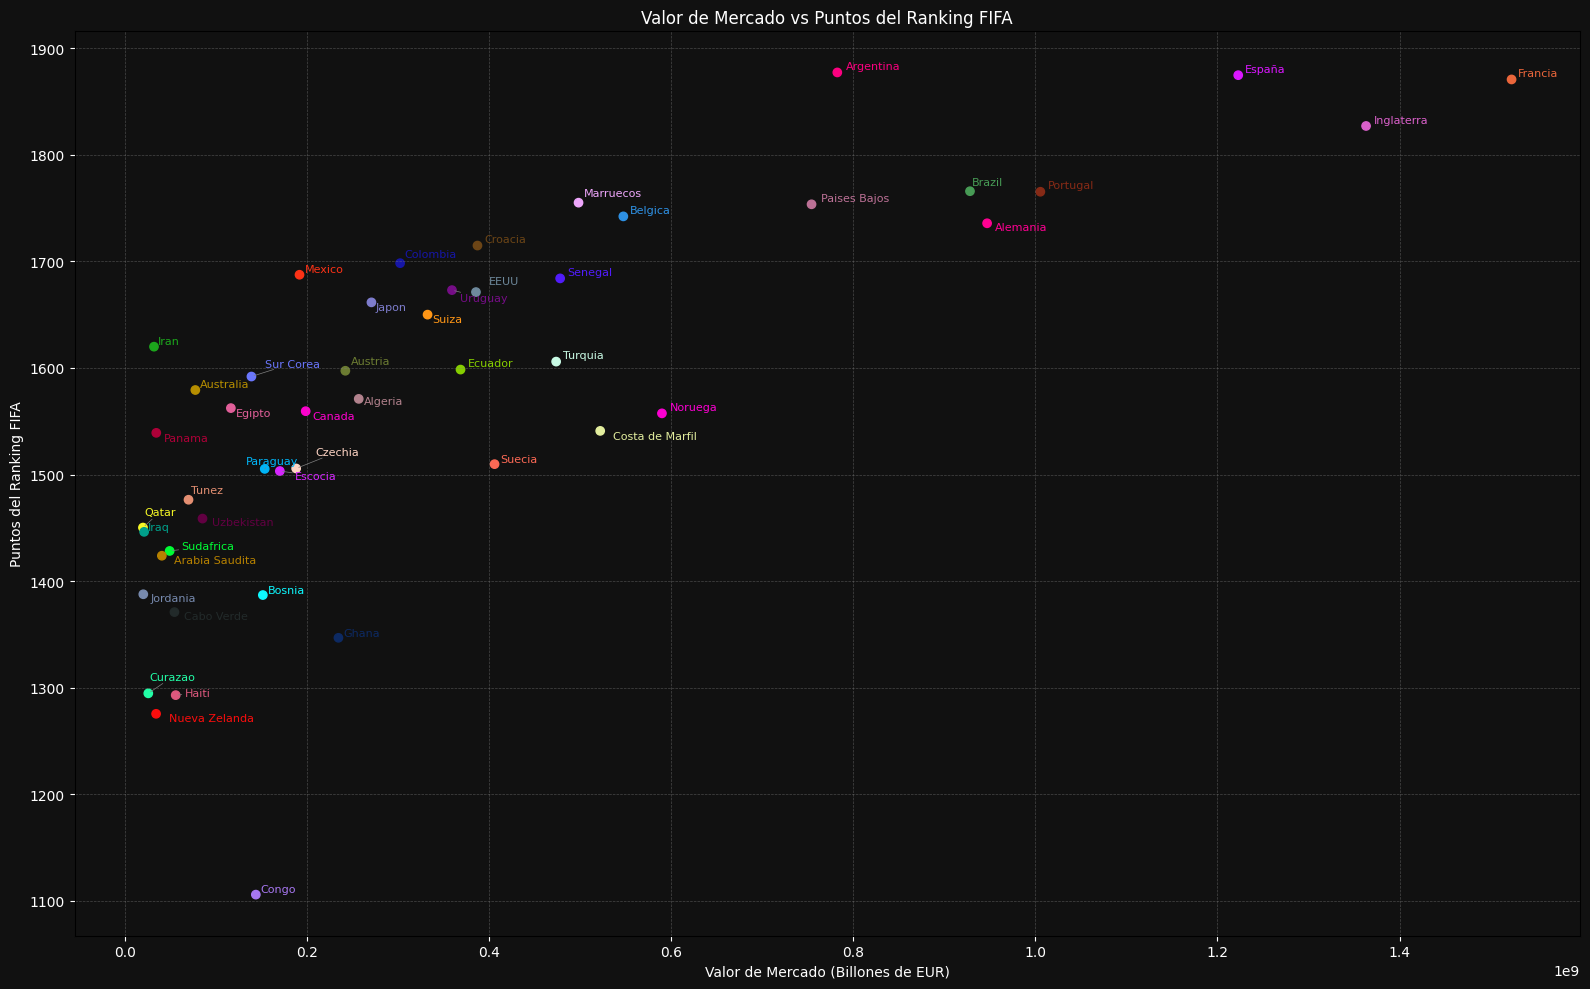

In [84]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
import plotly.express as px

base_colors = px.colors.qualitative.Light24 + px.colors.qualitative.Dark24
colors = base_colors[:len(df_all_groups)]

fig, ax = plt.subplots(figsize=(16, 10), facecolor="#111111")
ax.set_facecolor("#111111")
ax.grid(True, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

ax.scatter(df_all_groups["Market value"], df_all_groups["Points"], color=colors)

texts = [
    ax.text(row["Market value"], row["Points"], row["Team_x"], color=colors[i], fontsize=8)
    for i, (_, row) in enumerate(df_all_groups.iterrows())
]

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

ax.set_xlabel("Valor de Mercado (Billones de EUR)", color="white")
ax.set_ylabel("Puntos del Ranking FIFA", color="white")
ax.set_title("Valor de Mercado vs Puntos del Ranking FIFA", color="white")
ax.tick_params(colors="white")

plt.tight_layout()
plt.savefig(r"E:\VS projects\EDA Football\transfermarkt\scatter.png", dpi=150)
plt.show()
